# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

##### Data Dictionary Reference
| Column | Definition |
| ------ | ---------- |
| order_id | Unique ID of the order |
| customer_id | ID of the customer who ordered the food |
| restaurant_name | Name of the restaurant |
| cuisine_type | Cuisine ordered by the customer |
| cost_of_the_order | Cost of the order |
| day_of_the_week | Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday) |
| rating | Rating given by the customer out of 5 |
| food_preparation_time | Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation. |
| delivery_time | Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps |

### Importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Display float numbers with three digits to the right of the decimal point.
pd.set_option('display.float_format', lambda x: '%.3f' % x)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Read in foodhub data
df = pd.read_csv('~/Desktop/foodhub_order.csv')

In [ ]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.750,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.080,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.230,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.200,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.590,Weekday,4,25,24


In [ ]:
# last rows
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.310,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.180,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.220,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.180,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.450,Weekend,Not given,28,24


### **Question 1:** How many rows and columns are present in the data?

In [ ]:
# Print the shape of the data
print("There are", df.shape[0], 'rows and', df.shape[1],'columns in this dataset.')

There are 1898 rows and 9 columns in this dataset.


#### Observations: There are 1898 rows and 9 columns in this dataset.


### **Question 2:** What are the datatypes of the different columns in the dataset?

In [ ]:
# Print number of unique data datatypes and counts for each data type.
print(df.info());
print("-" * 50)
print("This data set includes", df.dtypes.nunique(), "data types:")
print(df.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB
None
--------------------------------------------------
This data set includes 3 data types:
int64      4
object     4
float64    1
Name: count, dtype: int64


#### Observations: Aside from order id and customer id, there are four categorical variables ("day of the week," "rating", "cuisine type," and "restaurant name") and three continuous variables ("cost of order," "food preparation time," and "delivery time").


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method.

In [ ]:
print(df.isnull().sum())
print("-" * 50)
print("There are", df.isnull().sum().sum(),"total missing values.")
# No null values

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64
--------------------------------------------------
There are 0 total missing values.


In [ ]:
print("There are", df.duplicated().sum().sum(),"total duplicated values.")
# No duplicated data

There are 0 total duplicated values.


#### Observations: No null or duplicated values in the data set.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?

In [ ]:
# Description of data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.000,1477495.500,548.050,1476547.000,1477021.250,1477495.500,1477969.750,1478444.000
customer_id,1898.000,171168.478,113698.140,1311.000,77787.750,128600.000,270525.000,405334.000
cost_of_the_order,1898.000,16.499,7.484,4.470,12.080,14.140,22.297,35.410
food_preparation_time,1898.000,27.372,4.632,20.000,23.000,27.000,31.000,35.000
delivery_time,1898.000,24.162,4.973,15.000,20.000,25.000,28.000,33.000


#### Observations: There are an equal number of entries for all continuous variables. The means and medians are relatively close for "cost of the order," "food preparation time," and "delivery time," suggesting that they are normally distributed.



### **Question 5:** How many orders are not rated?

In [ ]:
print("There are", df['rating'].value_counts().iloc[0], "orders with no rating.");

There are 736 orders with no rating.


#### Observations: There are 736 orders with no rating.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions.

In [ ]:
# Print number of customer ids and user ids and number of restaurants
print("There are", df['customer_id'].nunique(), "unique customer ids.")
print("There are", df['order_id'].nunique(), "unique order ids.")
print("There are", df['restaurant_name'].nunique(), "unique restaurants.")

There are 1200 unique customer ids.
There are 1898 unique order ids.
There are 178 unique restaurants.


---------------------------------------------------------------------------------------------------------
                                               cuisine_type                                              
---------------------------------------------------------------------------------------------------------


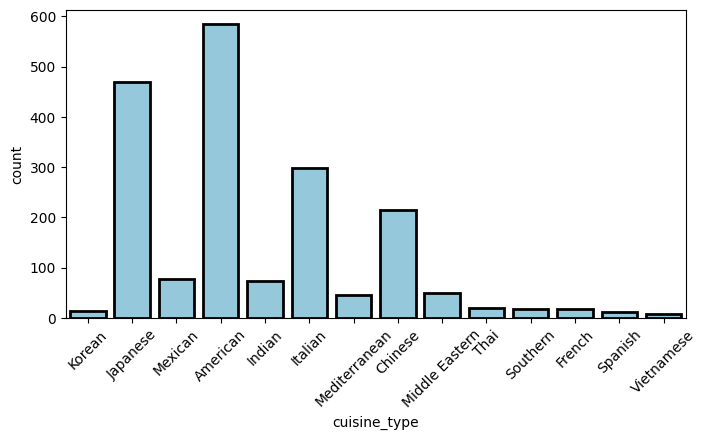

---------------------------------------------------------------------------------------------------------
                                             day_of_the_week                                             
---------------------------------------------------------------------------------------------------------


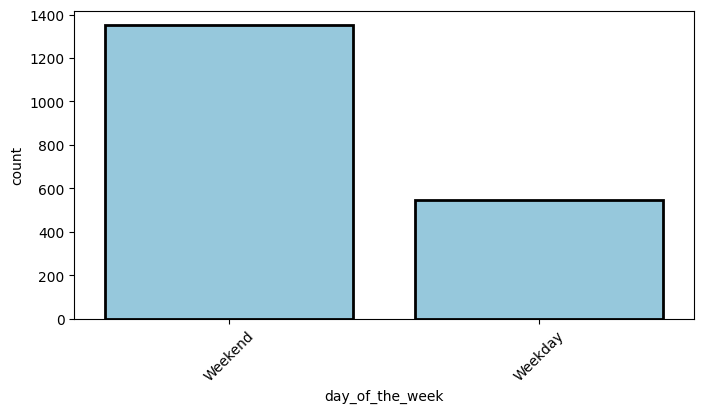

---------------------------------------------------------------------------------------------------------
                                                  rating                                                 
---------------------------------------------------------------------------------------------------------


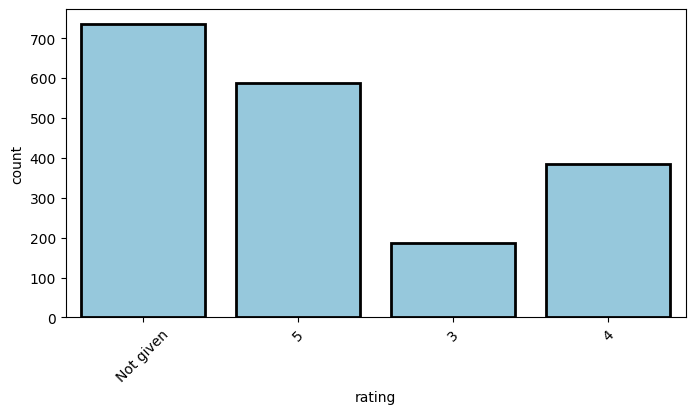

In [ ]:
# Make Countplots for all categorical variables

# Drop restaurants
df_norest = df.drop(columns=['restaurant_name'])

# Data types of all columns
dt_obj = df_norest.dtypes == 'object'
obj_cols = dt_obj[dt_obj == True].index

for numb,i in enumerate(obj_cols):
  print("-" * 105)
  txt = i
  print(txt.center(105))
  print("-" * 105)
  plt.figure(figsize=(8,4))
  sns.countplot(data=df_norest,x=df[i], color='skyblue', saturation=0.7,edgecolor='black', linewidth=2);
  plt.xticks(rotation=45)
  plt.show();

-----------------------------------------------------------------------------------------------
                                       cost_of_the_order                                       
-----------------------------------------------------------------------------------------------


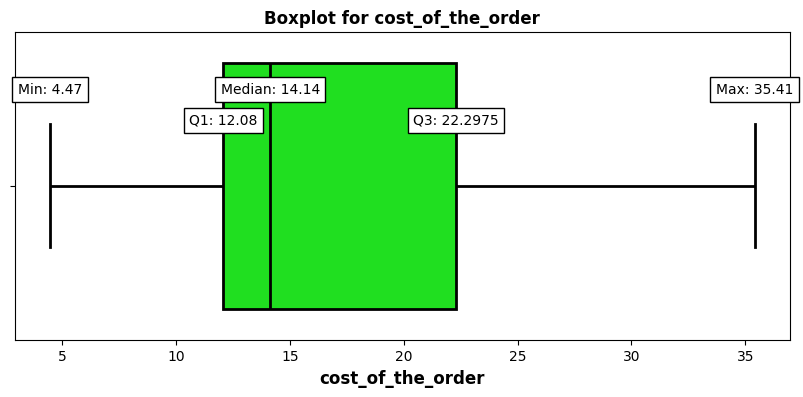

-----------------------------------------------------------------------------------------------
                                     food_preparation_time                                     
-----------------------------------------------------------------------------------------------


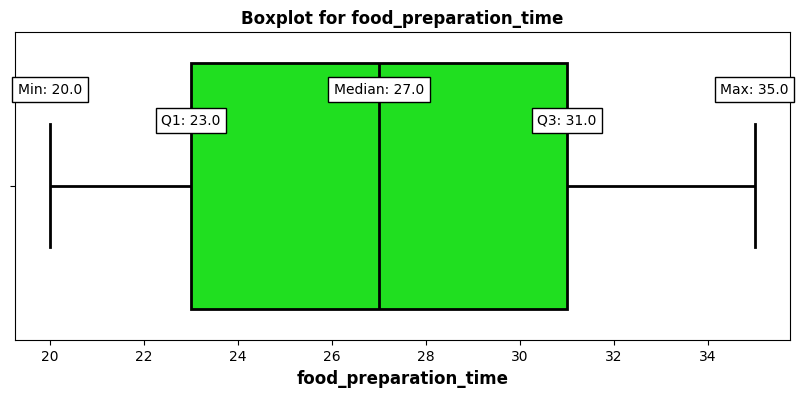

-----------------------------------------------------------------------------------------------
                                         delivery_time                                         
-----------------------------------------------------------------------------------------------


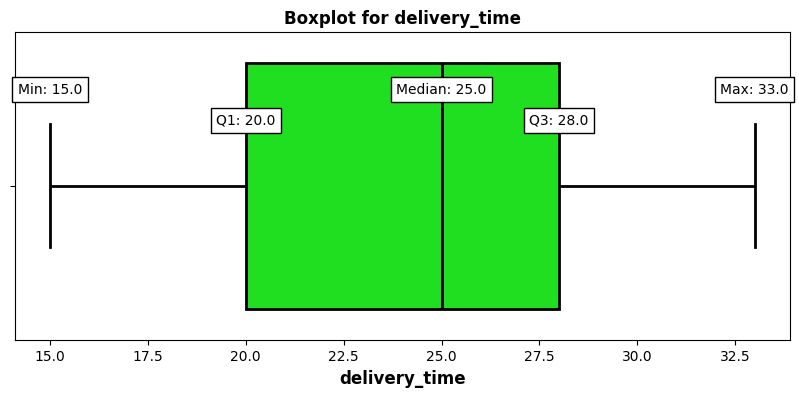

In [ ]:
# Make boxplots for delivery time, cost of order, and order prep time

# Data types of all columns
df_cont = df.drop(columns=['restaurant_name','day_of_the_week','order_id','customer_id','rating','cuisine_type'])
#print(df_cont)

for numb, i in enumerate(df_cont):
  print("-" * 95)
  txt = i
  print(txt.center(95))
  print("-" * 95)
  # Create boxplot for cost of orders.
  plt.figure(figsize=(10, 4))
  box_plot = sns.boxplot(x=df_cont[i], color=[0,1,0], linewidth = 2, linecolor='black', legend=False)
  plt.xlabel(i, fontsize=12, fontweight='bold')
  plt.title('Boxplot for ' + i, fontsize=12, fontweight='bold')

  # Calculate quartiles and median
  Min = df_cont[i].quantile(0)
  Q1 = df_cont[i].quantile(0.25)
  Q3 = df_cont[i].quantile(0.75)
  Max = df_cont[i].quantile(1)
  median = df_cont[i].median()

  # Set the labels, title, position, fontsize and alignment for the output.
  plt.text(x=Min, y=-0.3, s=f'Min: {Min}', color='black', ha='center', bbox=dict(facecolor='white', alpha=1,edgecolor = 'black'))
  plt.text(x=Q1, y=-0.2, s=f'Q1: {Q1}', color='black', ha='center', bbox=dict(facecolor='white', alpha=1,edgecolor = 'black'))
  plt.text(x=Q3, y=-0.2, s=f'Q3: {Q3}', color='black', ha='center', bbox=dict(facecolor='white', alpha=1,edgecolor = 'black'))
  plt.text(x=median, y=-0.3, s=f'Median: {median}', color='black', ha='center', bbox=dict(facecolor='white', alpha=1,edgecolor = 'black'))
  plt.text(x=Max, y=-0.3, s=f'Max: {Max}', color='black', ha='center', bbox=dict(facecolor='white', alpha=1,edgecolor = 'black'))
  plt.show()

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received?

In [ ]:
# List restaurants with most orders (top 5)
top5 = df['restaurant_name'].value_counts().reset_index().head(5)

print(top5.to_string(index=False))

          restaurant_name  count
              Shake Shack    219
        The Meatball Shop    132
        Blue Ribbon Sushi    119
Blue Ribbon Fried Chicken     96
                     Parm     68


#### Observations: The restaurants with the most orders are (in order):
1. Shake Shack
2. The Meatball Shop
3. Blue Ribbon Sushi
4. Blue Ribbon Fried Chicken, and
5. Parm

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().head(1)
print("The most popular cuisine on weekends is ", df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().index[0],'.',sep='')

The most popular cuisine on weekends is American.


#### Observations: The most popular cuisine on weekends is American.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Sum the number of orders over $20
Orders_over_20_dollars = df[df['cost_of_the_order'] > 20].value_counts().sum()

# Sum all orders
Total_orders = df['cost_of_the_order'].value_counts().sum()

# calculate the percent of orders that cost more than $20
percent_order_over_20 = round(Orders_over_20_dollars / Total_orders * 100, 2)
print(percent_order_over_20, "% of orders cost more than $20.",sep='')

29.24% of orders cost more than $20.


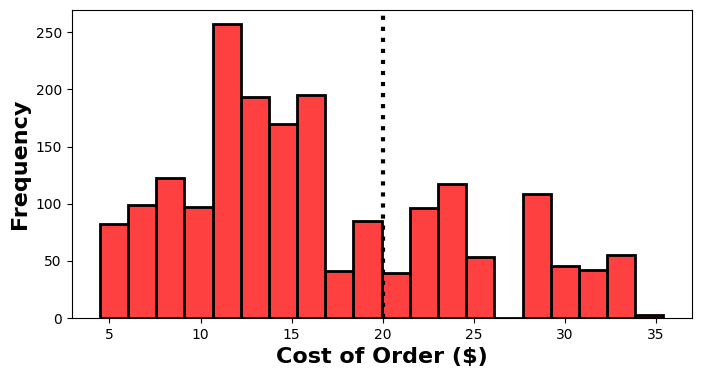

In [ ]:
# Visulalizing the 29.24%
plt.figure(figsize=(8, 4))
sns.histplot(df['cost_of_the_order'], bins=20, edgecolor='black',linewidth = 2, color='red')
plt.xlabel('Cost of Order ($)', fontsize=16, fontweight='bold')
plt.ylabel('Frequency', fontsize=16, fontweight='bold')
plt.axvline(20, color='black', linestyle='dotted', linewidth=3)

# Show histogram.
plt.show()

#### Observations: Most orders (71.76%) are under $20.


### **Question 10**: What is the mean order delivery time?

In [ ]:
print("The mean delivery time is", df['delivery_time'].mean().round(2), "minutes.")

The mean delivery time is 24.16 minutes.


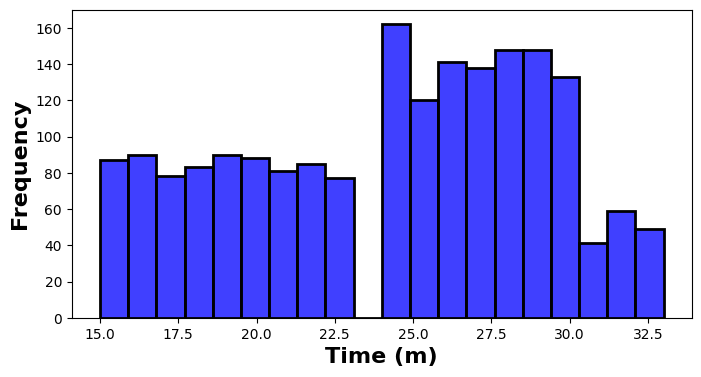

In [ ]:
# Visualize distribution of delivery times
plt.figure(figsize=(8, 4))
sns.histplot(df['delivery_time'], bins=20, edgecolor='black',linewidth = 2, color='blue')
plt.xlabel('Time (m)', fontsize=16, fontweight='bold')
plt.ylabel('Frequency', fontsize=16, fontweight='bold')

# Show histogram.
plt.show()

#### Observations: The mean delivery time is 24.16 minutes.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
top3 = df['customer_id'].value_counts().head(3)
print("Contratulations to the following customers who will receive a 20% discount voucher:")
for i in top3.index:
  print("Customer ID:", i, "placed", top3[i], "orders.")

Contratulations to the following customers who will receive a 20% discount voucher:
Customer ID: 52832 placed 13 orders.
Customer ID: 47440 placed 10 orders.
Customer ID: 83287 placed 9 orders.


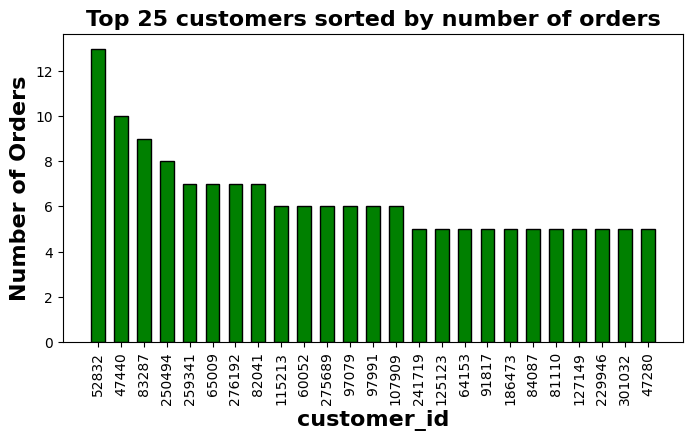

In [ ]:
# Visualize distribution of delivery times for top 25 customers
xdata = df['customer_id'].value_counts().head(25)
xdata.index = xdata.index.astype(str)

# plot figure
plt.figure(figsize=(8, 4))
plt.bar(xdata.index,xdata,linewidth = 1,color='green',width=0.6, edgecolor = 'black');
plt.xticks(rotation=90)
plt.title('Top 25 customers sorted by number of orders', fontsize=16, fontweight='bold')
plt.xlabel('customer_id', fontsize=16, fontweight='bold')
plt.ylabel('Number of Orders', fontsize=16, fontweight='bold')
plt.show()

#### Observations: Customers 52832, 47440, and 250494 made the most orders, but they were closely followed by several other customers.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset.


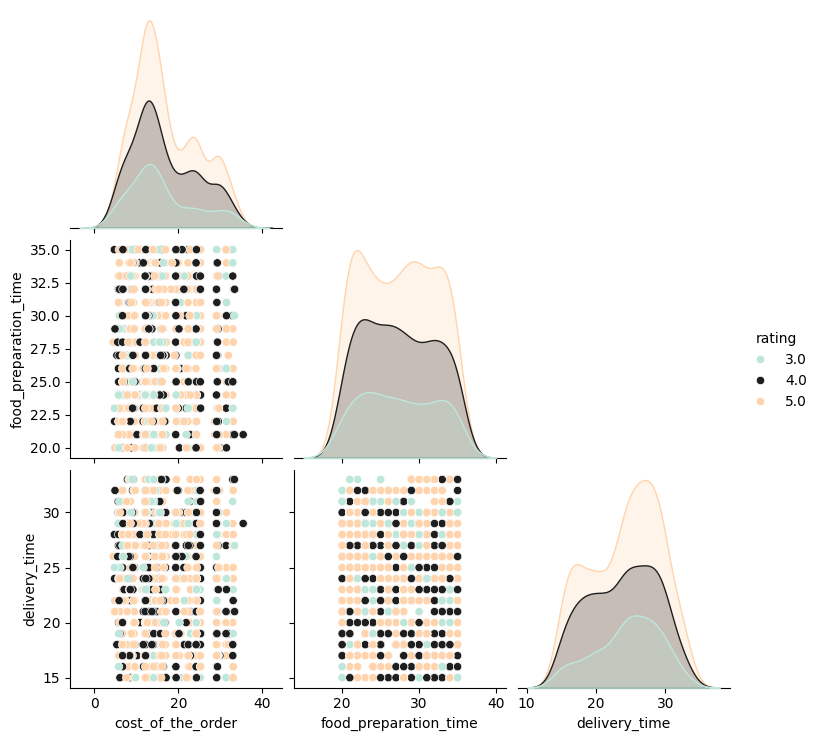

In [ ]:
# Plot correlations between continuous variables and divide them by rating

# Remove categorical variables to examine relationship between continuous ones
df_corr_data = df.drop(columns=['restaurant_name','cuisine_type','day_of_the_week','order_id','customer_id']).copy()

# Replacing missing values with nan
df_corr_data['rating'] = df_corr_data['rating'].replace(['Not given'],np.nan)

# changing the rating data type to float so that it can be regressed against other variables
df_corr_data['rating'] = df_corr_data['rating'].astype(float)

# Pair plot to examine relationship between continuous variables
sns.pairplot(data=df_corr_data, vars = ['cost_of_the_order','food_preparation_time','delivery_time'], hue='rating',palette = 'icefire',corner=True);

# There does not appear to be any association between:
# 1. Food prep time and cost of order
# 2. delivery time and cost of order
# 3. delivery time and food prep time

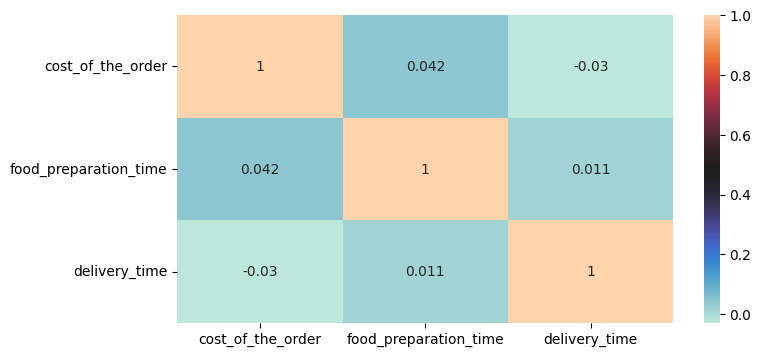

In [ ]:
# Heat plot between continuous variables
plt.subplots(figsize=(8,4))
sns.heatmap(data=df[['cost_of_the_order','food_preparation_time','delivery_time']].corr(), annot=True, cmap='icefire');

# Recapulation of pair plot, but with correlation values

----------------------------------------------------------------------------------------------------


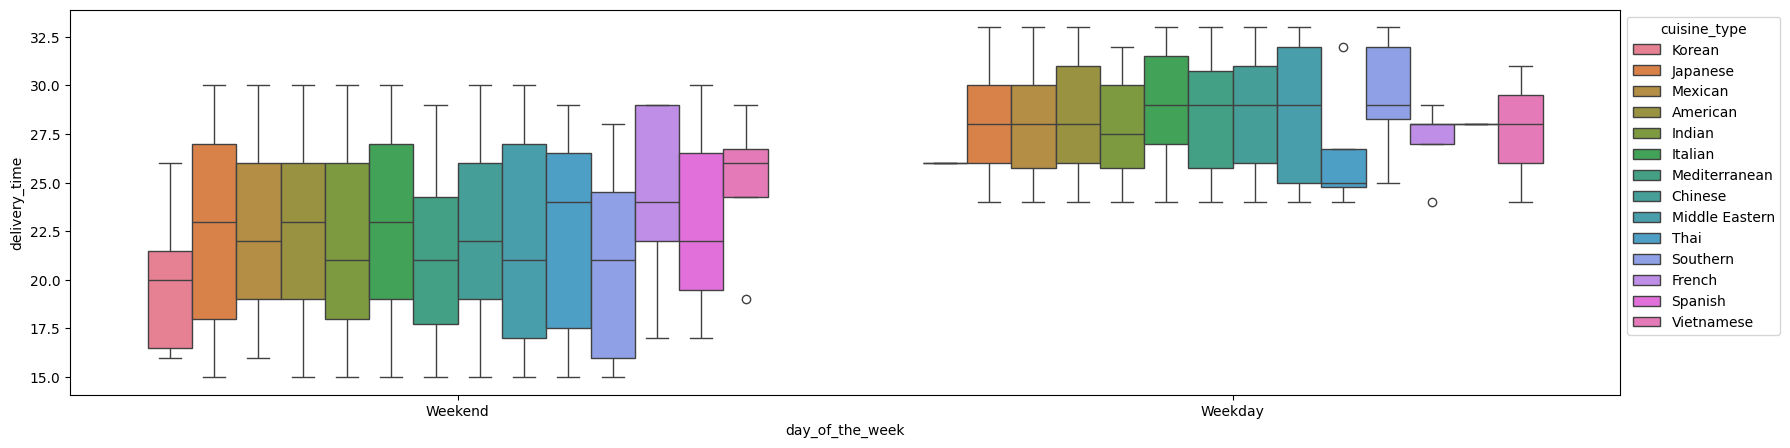

----------------------------------------------------------------------------------------------------


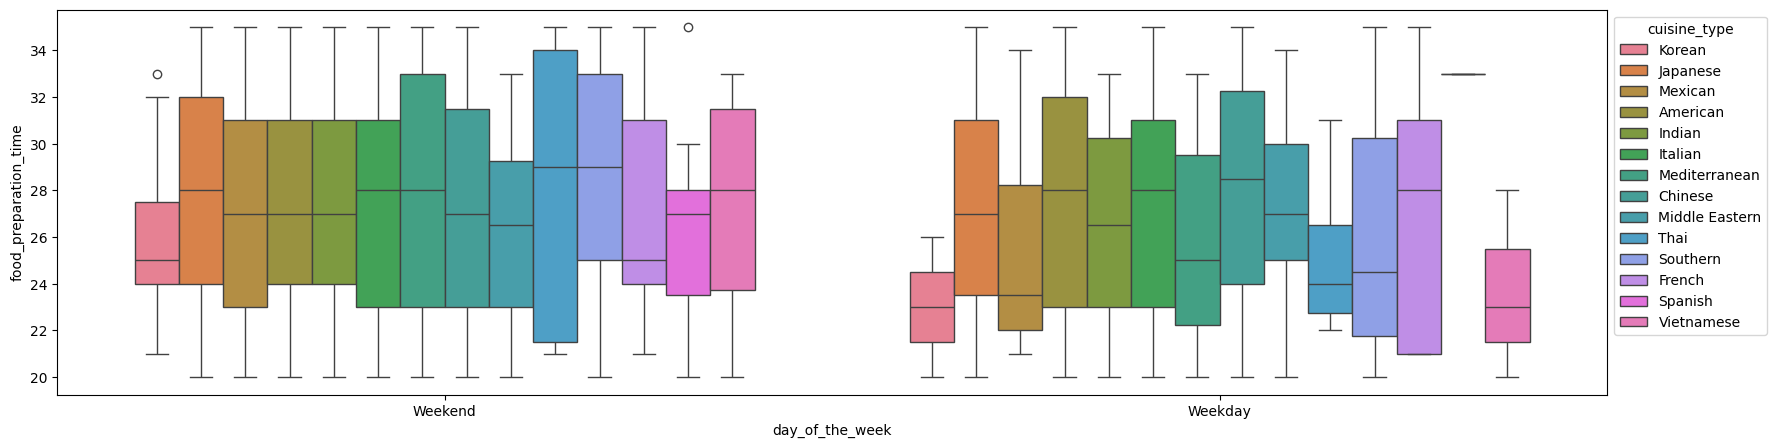

----------------------------------------------------------------------------------------------------


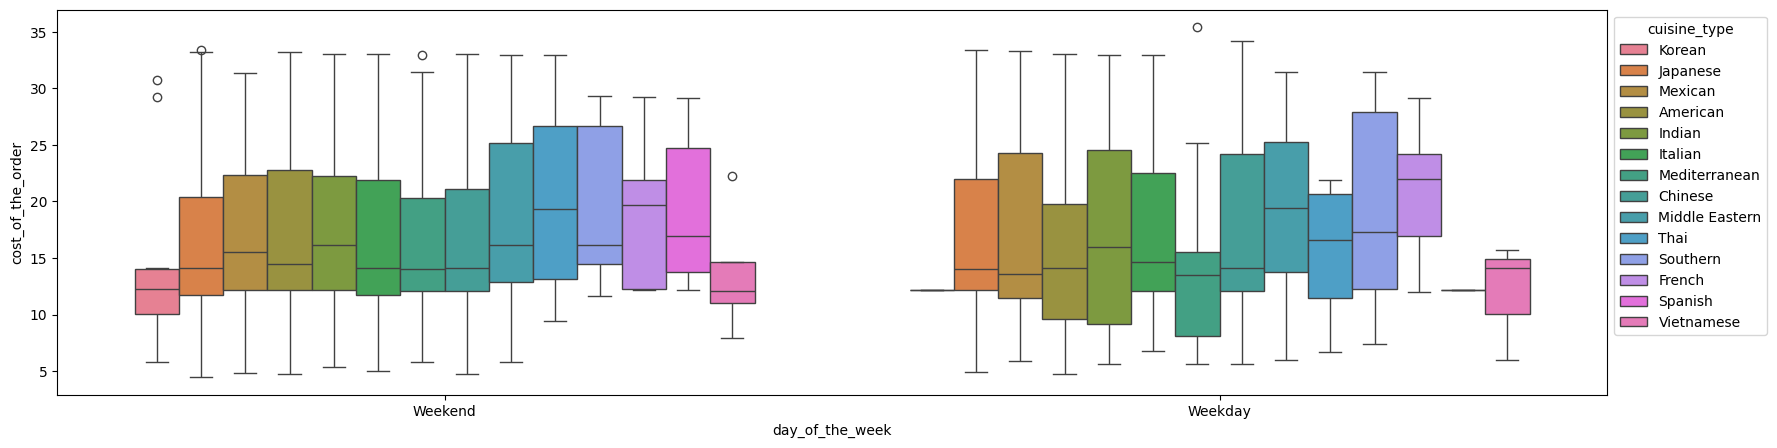

In [ ]:
# Examining how delivery_time is affected by day of the week and type of food ordered
plt.figure(figsize=(20,5))
fig1 = sns.boxplot(data=df,x='day_of_the_week',y='delivery_time',hue='cuisine_type')
sns.move_legend(fig1, "upper left", bbox_to_anchor=(1, 1))
print("-" * 100)
plt.show()

# Examining how food preparation time is affected by day of the week and type of food ordered
plt.figure(figsize=(20,5))
fig2 = sns.boxplot(data=df,x='day_of_the_week',y='food_preparation_time',hue='cuisine_type')
sns.move_legend(fig2, "upper left", bbox_to_anchor=(1, 1))
print("-" * 100)
plt.show()

# Examining how food cost_of_the_order is affected by day of the week and type of food ordered
plt.figure(figsize=(20,5))
fig3 = sns.boxplot(data=df,x='day_of_the_week',y='cost_of_the_order',hue='cuisine_type')
sns.move_legend(fig3, "upper left", bbox_to_anchor=(1, 1))
print("-" * 100)
plt.show()

# Food prep time and order cost are not affected by the day of the week, but delivery time appears to go down on weekends.
# Korean and Vietnamese restaurants tend to have the lowest food prep time, delivery time, and order costs, regardless of the day of the week.

In [ ]:
# Total sum of sales by restaurant

# Make a list of the sum of all sales from each restaurant
pd.set_option('display.max_rows', None)
df_sales = df.groupby(df['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending=False);
print(df_sales);
print("-" * 100)

# Only ~3% of restaurants have sales over $1000 and Shake Shack leads them at $3579.53

restaurant_name
Shake Shack                             3579.530
The Meatball Shop                       2145.210
Blue Ribbon Sushi                       1903.950
Blue Ribbon Fried Chicken               1662.290
Parm                                    1112.760
RedFarm Broadway                         965.130
RedFarm Hudson                           921.210
TAO                                      834.500
Han Dynasty                              755.290
Blue Ribbon Sushi Bar & Grill            666.620
Rubirosa                                 660.450
Sushi of Gari 46                         640.870
Nobu Next Door                           623.670
Five Guys Burgers and Fries              506.470
Momoya                                   492.130
Chipotle Mexican Grill $1.99 Delivery    491.690
Blue Ribbon Sushi Izakaya                485.090
Tamarind TriBeCa                         426.710
Jack's Wife Freda                        416.750
Bareburger                               399.740
Sush

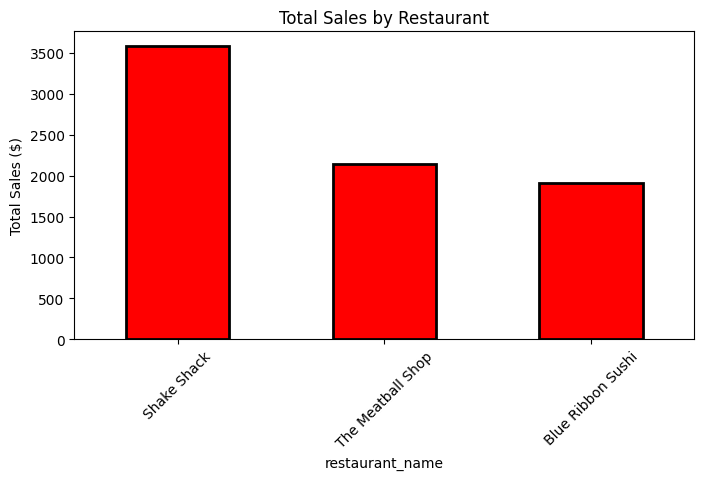

In [ ]:
# plot the total sales for the top 3 restaurants
plt.figure(figsize=(8,4))
df_sales_plot = df.groupby(df['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending=False).head(3).plot(kind='bar',edgecolor = 'black', linewidth = 2,color='red',ylabel ='Total Sales ($)');
title = df_sales_plot.set_title('Total Sales by Restaurant');
plt.xticks(rotation=45)
plt.show()


In [ ]:
# pct of restaurants with sales over $1000
numb_rest_over_1k = df_sales[df_sales > 1000].value_counts().sum()
total_rest = df_sales.value_counts().sum()
pct_over_1k = round(numb_rest_over_1k / total_rest * 100, 2)
print(pct_over_1k, "% of restaurants had sales over $1000.")

2.81 % of restaurants had sales over $1000.


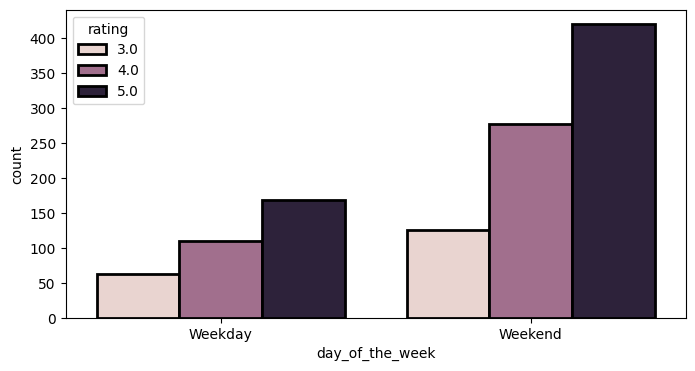

In [ ]:
# Examining the number of orders by rating and day of the week
data_tmp = df[df['rating'] != 'Not given'].drop(columns=['restaurant_name','cuisine_type','order_id','customer_id'])
data_tmp['rating'] = data_tmp['rating'].astype(float)

# plot the number of restaurant orders by rating and day of week
plt.figure(figsize=(8,4))
sns.countplot(data=data_tmp,x='day_of_the_week', hue = 'rating', edgecolor = 'black', linewidth = 2);

# Generally, the same proportion of 3,4, and 5 ratings are given on weekdays and weekends, but the total number of orders goes up on weekends.

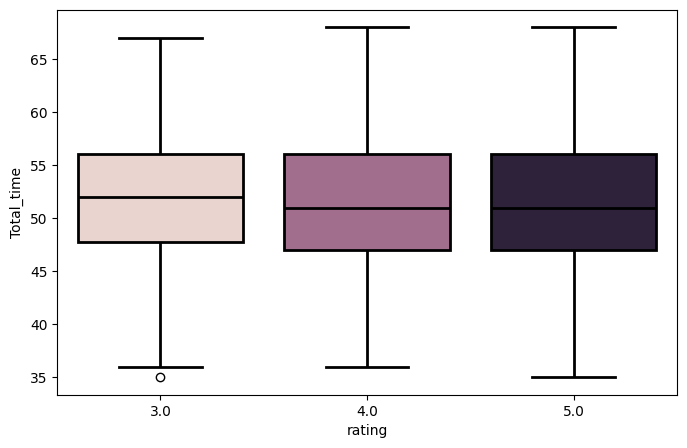

In [ ]:
# Examining how total time differs across ratings
data_tmp['Total_time'] = data_tmp['food_preparation_time'] + data_tmp['delivery_time']

# Plot the total time taken to receive delivery by rating
plt.figure(figsize=(8,5))
fig4 = sns.boxplot(data=data_tmp,x='rating',y='Total_time',hue='rating',linecolor = 'black',linewidth = 2,legend = False);
plt.show()

# The time between the order and receiving the food doesn't appear to affect the rating given.

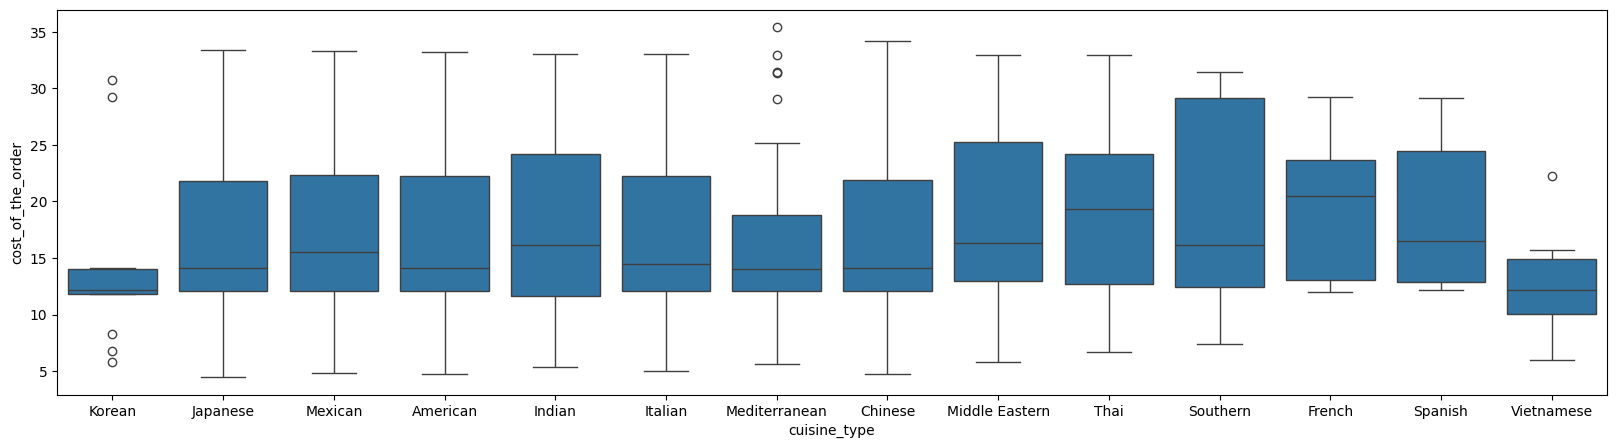

In [ ]:
# Examining how the cost of an order differs across cuisine types
plt.figure(figsize=(20,5))
sns.boxplot(data=df,x='cuisine_type',y='cost_of_the_order');
plt.show()

# Costs appear to be lowest for Korean and Vietnamese orders give or take a few outliers.

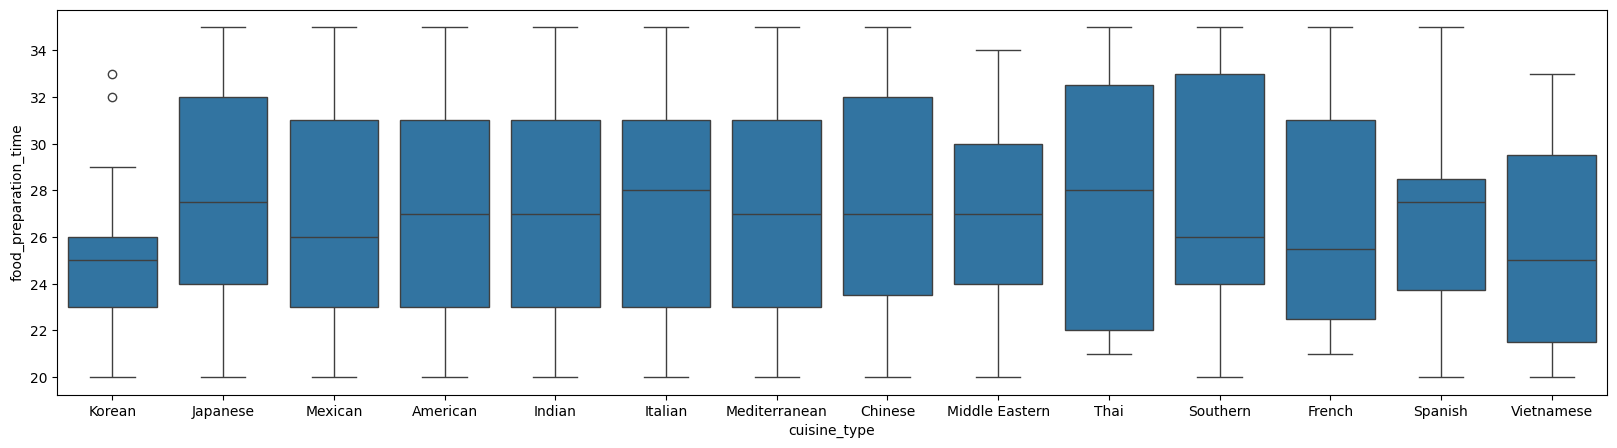

----------------------------------------------------------------------------------------------------
The fastest restaurants in terms of delivery time are:
Spanish is 26.92 minutes.
Thai is 27.32 minutes.
Vietnamese is 25.71 minutes.


In [ ]:
# Examining how the preparation time differs across cuisine types
plt.figure(figsize=(20,5))
sns.boxplot(data=df,x='cuisine_type',y='food_preparation_time');
plt.show()
print("-" * 100)
fastest_restaurants = df.groupby(df['cuisine_type'])['food_preparation_time'].mean().tail(3)

# names of fastest restaurants
print("The fastest restaurants in terms of delivery time are:")
for i in fastest_restaurants.index:
  print(i, "is", fastest_restaurants[i].round(2), "minutes.")

# The fastest prep times are for Spanish, Thai, and Vietnamese restaurants.

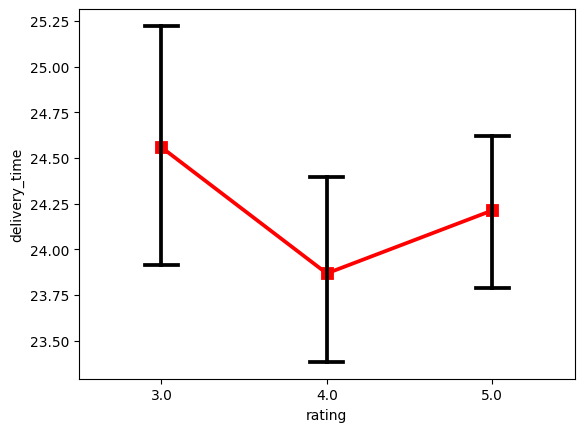

----------------------------------------------------------------------------------------------------
The delivery times for each rating are:
3.0 is 24.56 minutes.
5.0 is 24.21 minutes.
4.0 is 23.87 minutes.


In [ ]:
# The relationship between rating and delivery_time
sns.pointplot(x = 'rating', y = 'delivery_time', data = data_tmp,color='red',marker= 's',capsize = 0.2, err_kws={'color': 'black'});
plt.show()
print("-" * 100)
ratings = data_tmp.groupby(data_tmp['rating'])['delivery_time'].mean().tail(3).sort_values(ascending = False)

# delivery times by rating
print("The delivery times for each rating are:")
for i in ratings.index:
  print(i, "is", ratings[i].round(2), "minutes.")

# The lowest ratings are given for the orders with particularly slower delivery times (~24.50 minutes on average).
# However there is a wide amount of variation in the "3" ratings across delivery time.

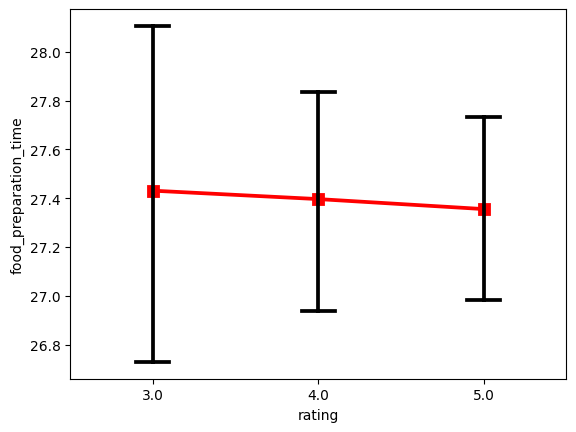

----------------------------------------------------------------------------------------------------
The food prep times for each rating are:
3.0 is 27.43 minutes.
4.0 is 27.4 minutes.
5.0 is 27.36 minutes.


In [ ]:
# The relationship between rating and food_preparation time
sns.pointplot(x = 'rating', y = 'food_preparation_time', data = data_tmp,color='red',marker= 's',capsize = 0.2, err_kws={'color': 'black'});
plt.show()
print("-" * 100)
ratings_fp = data_tmp.groupby(data_tmp['rating'])['food_preparation_time'].mean().tail(3).sort_values(ascending = False)

# delivery times by rating
print("The food prep times for each rating are:")
for i in ratings_fp.index:
  print(i, "is", ratings_fp[i].round(2), "minutes.")

# rating doesn't depend on food preparation time.

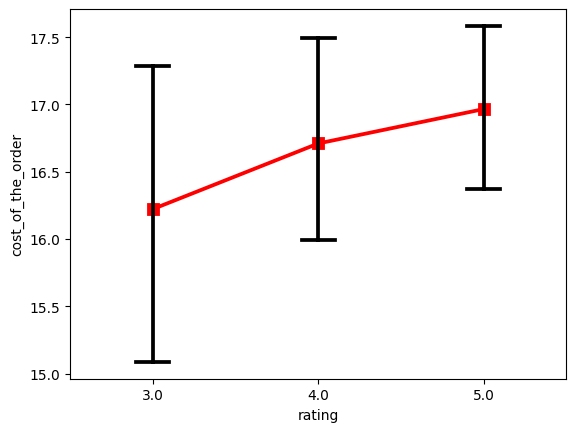

----------------------------------------------------------------------------------------------------
The food prep times for each rating are:
5.0 is 16.97 minutes.
4.0 is 16.71 minutes.
3.0 is 16.22 minutes.


In [ ]:
# The relationship between rating and cost
sns.pointplot(x = 'rating', y = 'cost_of_the_order', data = data_tmp,color='red',marker= 's',capsize = 0.2, err_kws={'color': 'black'});
plt.show()
print("-" * 100)
ratings_cost = data_tmp.groupby(data_tmp['rating'])['cost_of_the_order'].mean().tail(3).sort_values(ascending = False)

# delivery times by rating
print("The food prep times for each rating are:")
for i in ratings_cost.index:
  print(i, "is", ratings_cost[i].round(2), "minutes.")

# Orders with a low average cost (~$16.25) get low ratings.
# However, there is wide variation in the cost of orders for "3" ratings.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.

In [ ]:
# Write the code here

# Replace "Not given" values with nans and change the data type to float
df['new_rating'] = df['rating'].replace(['Not given'],np.nan)
df['new_rating'] = df['new_rating'].astype(float)

# restaurants with ratings higher than 50
df_ratings = df.groupby(df['restaurant_name'])['new_rating'].count().sort_values(ascending = False) > 50
ratings_rests = df_ratings[df_ratings == True].index
print("Restaurants with more than 50 ratings:")
for i in ratings_rests:
  print(i)

print("-" * 50)

# restaurants with average_ratings greater than 4
df_means = df.groupby(df['restaurant_name'])['new_rating'].mean().sort_values(ascending = False)
means_rests = df_means[df_means > 4].index
print("Restaurants with a mean rating of 4:")
for i in means_rests:
  print(i)

print("-" * 50)

# See below for restaurants satisfying both criteria.

Restaurants with more than 50 ratings:
Shake Shack
The Meatball Shop
Blue Ribbon Sushi
Blue Ribbon Fried Chicken
--------------------------------------------------
Restaurants with a mean rating of 4:
'wichcraft
67 Burger
Anjappar Chettinad
Asuka Sushi
Balade
Cafe de La Esquina
Big Daddy's
Bhatti Indian Grill
Bukhara Grill
Kanoyama
Olive Garden
Lantern Thai Kitchen
Hot Kitchen
Hunan Manor
Klong
Dos Caminos Soho
Grand Sichuan International
Haru Gramercy Park
El Parador Cafe
Galli Restaurant
Dos Caminos
DespaÌ±a
Donburi-ya
Dig Inn Seasonal Market
Chola Eclectic Indian Cuisine
Chote Nawab
Cipriani Le Specialita
Carmine's
Yama 49
UVA Wine Bar & Restaurant
Tortaria
da Umberto
Vezzo Thin Crust Pizza
Xe May Sandwich Shop
Moonstruck on Second
Vanessa's Dumpling House
Taro Sushi
Saravanaa Bhavan
Socarrat Paella Bar
Song Thai Restaurant & Bar
Samurai Mama
Ravagh Persian Grill
Prosperity Dumpling
Philippe Chow
Junoon
Mission Cantina
Kambi Ramen House
Sushi Samba
Otto Enoteca Pizzeria
Lucky's Famo

In [ ]:
# Find overlapping restaurants betweent the two lists
overlapping_rests = ratings_rests.intersection(means_rests)
print("Restaurants with more than 50 ratings and a mean rating of 4:")
overlapping_rests
for i in overlapping_rests:
  print(i)

  # Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken are the only restaurants with more than 50 ratings that average above 4.

Restaurants with more than 50 ratings and a mean rating of 4:
Shake Shack
The Meatball Shop
Blue Ribbon Sushi
Blue Ribbon Fried Chicken


#### Observations: Only four restaurants had a mean rating > 4 and 50 ratings:
1. Shake Shack
2. The Meatball Shop
3. Blue Ribbon Sushi, and
4. Blue Ribbon Fried Chicken


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.

In [ ]:
# Find net revenue
net_revenue = 0
for i in df['cost_of_the_order']:
  if i > 20:
    net_revenue += i*0.25
  elif i > 5:
    net_revenue += i*0.15

print("The net revenue generated by the company across all orders is $", round(net_revenue,2), ".",sep = '')

# The company made a net revenue of $6166.3

The net revenue generated by the company across all orders is $6166.3.


#### Observations: The company made a net revenue of $6166.3

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed?

In [ ]:
# Total time to deliver food
df['Total_time'] = df['food_preparation_time'] + df['delivery_time']

# calculate number of slower deliveries (> 60 minutes total time)
slow_deliveries = df[df['Total_time'] > 60].shape[0]

# calculate number of deliveries
total_deliveries = df.shape[0]

# calculate percentage of deliveries that take longer than 60 minutes
pct_slow = round(slow_deliveries / total_deliveries * 100, 2)
print(pct_slow, "% of orders take more than 60 minutes to get delivered.",sep='')

# Very few orders (6.27%) exceed 60 minutes from time of order to food arrival.

10.54% of orders take more than 60 minutes to get delivered.


#### Observations: Very few orders (6.27%) exceed 60 minutes from time of order to food arrival.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [ ]:
# Delivery time by day of the week

# Group the day of the week and list the mean delivery times for each
by_week = df.groupby(df['day_of_the_week'])['delivery_time'].mean()
print("The mean delivery time on the weekdays is", round(by_week.iloc[0]), "minutes.")
print("The mean delivery time on the weekends is", round(by_week.iloc[1]), "minutes.")

# What is the difference in average delivery time between weekdays and weekends
diff_week = by_week.iloc[0] - by_week.iloc[1]
print("The difference in mean delivery time between weekdays and weekends is", round(diff_week), "minutes in favor of weekdays.")

# Delivery times go down on weekends by about 6 minutes

The mean delivery time on the weekdays is 28 minutes.
The mean delivery time on the weekends is 22 minutes.
The difference in mean delivery time between weekdays and weekends is 6 minutes in favor of weekdays.


#### Observations: Delivery times go down on weekends by about 6 minutes

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
#### **Univariate**
###### 1. Only a few restaurants have over 100 orders.
###### 2. American and Japenese restaurants are most commonly ordered.
###### 3. Most orders are between 10-15 dollars, although the average is around $16.

###### 4. Mean food preparation time is about 27 minutes with a standard deviation of  4.5. While a few food preparation times (e.g., 20,25) are more common, overall it seems that all delivery times are equally likely to occur. It also seems that food preparation time does not affect ratings (see below).

##### 5. The mean delivery time is 24 minutes with a standard deviation of about 5.

#### **Multivariate**

###### 1. There does not appear to be any association between:
###### Food prep time and cost of order
###### Delivery time and cost of order
###### Delivery time and food prep time

###### 2. Food prep time and order cost are not strongly affected by the day of the week.

###### 3. Korean and Vietnamese restaurants tend to have the lowest food prep time, delivery time, and order costs, regardless of the day of the week.

###### 4. Only ~3% of restaurants have sales over 1000 dollars and Shake Shack leads them at $3579.53.

###### 5. Generally, the same proportion of 3,4, and 5 ratings are given on weekdays and weekends.

###### 6. The time between the order and receiving the food doesn't appear to affect the rating given.

###### 7. Costs appear to be lowest for Korean and Vietnamese orders give or take a few outliers.

###### 8. The fastest prep times are for Spanish, Thai, and Vietnamese restaurants.

###### 9.The lowest ratings are given for the orders with particularly slower delivery times (~24.50 minutes on average). However there is a wide amount of variation in the "3" ratings across delivery time.

###### 10. Ratings don't appear to depend on food preparation time.

###### 11. Orders with a low average cost (~$16.25) get low ratings. However, there is wide variation in the cost of orders for "3" ratings.

###### 12. Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken are the only restaurants with more than 50 ratings that average above 4.

###### 13. The company made a net revenue of $6166.3.

###### 14. Very few orders (6.27%) exceed 60 minutes from time of order to food arrival.

###### 15. Delivery times go down and order costs go up on weekends.

### Recommendations:

The company is likely to care about the cost of orders and customer ratings, since both help increase profits. Here are several recommendatiuons to maximize both.


1. The most number of orders come from American and Japanese food restaurants. Locating and partnering with businesses that sell these types of food may yield more profit.
2. There appears to be a delivery time threshold where ratings drop to the "3" level. Incentivizing lower delivery times for its slower carriers may help to decrease the number of lower ratings amongst apps users.
3. Since delivery times are higher on weekdays and delivery time may be related to lower ratings, incentivizing carriers on weekdays may drive up ratings amongst app users.
4. Lower food costs are likely associated with less food. Since there is some evidence that lower overall order costs bring down ratings, the company can distribute vouchers to increase the total cost of orders. This may increase rating scores amongst app users. Targeting users with particularly lower order costs may be particularly helpful.
5. Korean and Vietnamese restaurants are very good at reducing the wait between the order and food arrival, but have relatively low order costs. The company may think about helping these restaurants increase their sales. One strategy is for the restaurants to offer increasing discounts based on the amount of food ordered (e.g., 10% discount on orders of 20 dollars or more, 20% discount on orders of 30 dp;;ars or more, 30% discount on orders 50 dollars or more).

---